# Библиотеки

In [62]:
import os
import pandas as pd
import numpy as np

from scipy import stats
from statsmodels.stats.diagnostic import lilliefors
import statsmodels.api as sm
import pyreadstat # Приоритет для чтения PSPP
from savReaderWriter import SavReader

import seaborn as sns

In [2]:
def describe_extended(s):
    # расширенное (отдельно)
    stats = {
        "count": s.count(),
        "mean": s.mean(),
        "min": s.min(),
        "quantile_25": s.quantile(0.25),
        "median": s.median(),
        "quantile_75": s.quantile(0.75),
        "quantile_95": s.quantile(0.95),
        "max": s.max(),
        "mode": s.mode().tolist(),          # может быть несколько мод
        "var": s.var(),
        "std": s.std(),
        "skew": s.skew(),                   # асимметрия
        "kurtosis": s.kurtosis(),           # эксцесс (Fisher, т.е. excess kurtosis)
        "nunique": s.nunique(),
        "missing": s.isna().sum(),
    }
    return pd.Series(stats)

In [64]:
def cronbach_alpha_report(
    df: pd.DataFrame,
    *,
    dropna: str = "listwise",          # "listwise" (как чаще в SPSS) или "pairwise"
    min_n: int = 3,                    # минимум наблюдений для расчёта
    coerce_numeric: bool = True,
) -> dict:
    """
    Возвращает отчёт по Cronbach's alpha и диагностике пунктов.
    df: строки = респонденты, столбцы = пункты шкалы.
    dropna:
      - "listwise": удалить строки с любыми NaN по пунктам (SPSS-подобно)
      - "pairwise": корреляции/статистики считаются по доступным парам (менее похоже на SPSS)
    """

    X = df.copy()

    # 1) Оставляем только числовое
    if coerce_numeric:
        for c in X.columns:
            X[c] = pd.to_numeric(X[c], errors="coerce")
    X = X.select_dtypes(include=[np.number])

    # 2) Обработка пропусков
    if dropna == "listwise":
        Xc = X.dropna(axis=0, how="any")
    elif dropna == "pairwise":
        Xc = X  # дальше будем аккуратно с pairwise
    else:
        raise ValueError("dropna must be 'listwise' or 'pairwise'")

    # Служебная функция: обычная альфа по ковариационной матрице
    def _alpha_cov(data: pd.DataFrame) -> float:
        if dropna == "listwise":
            data = data.dropna(axis=0, how="any")
        if data.shape[0] < min_n or data.shape[1] < 2:
            return np.nan
        cov = data.cov(min_periods=min_n)  # при pairwise будет неполной, но pandas обработает
        k = cov.shape[0]
        v_sum = np.trace(cov.values)
        v_total = cov.values.sum()  # дисперсия суммы = сумма всех ковариаций
        if k <= 1 or v_total <= 0 or np.isnan(v_total):
            return np.nan
        return (k / (k - 1)) * (1 - (v_sum / v_total))

    # Standardized alpha (по средней межпунктовой корреляции)
    def _alpha_standardized(data: pd.DataFrame) -> float:
        if dropna == "listwise":
            data = data.dropna(axis=0, how="any")
        if data.shape[0] < min_n or data.shape[1] < 2:
            return np.nan
        R = data.corr(min_periods=min_n)
        k = R.shape[0]
        # средняя корреляция вне диагонали
        mask = ~np.eye(k, dtype=bool)
        rbar = R.values[mask].mean()
        if np.isnan(rbar):
            return np.nan
        return (k * rbar) / (1 + (k - 1) * rbar)

    # Базовые метрики
    alpha = _alpha_cov(Xc)
    alpha_std = _alpha_standardized(Xc)

    # Таблица "если пункт удалён" + item-total corr
    rows = []
    cols = list(Xc.columns)
    for col in cols:
        rest = [c for c in cols if c != col]
        a_del = _alpha_cov(Xc[rest])
        a_del_std = _alpha_standardized(Xc[rest])

        # item-total correlation: corr(item, sum(rest))
        tmp = Xc[[col] + rest].copy()
        if dropna == "listwise":
            tmp = tmp.dropna()
        # sum без текущего пункта
        total_rest = tmp[rest].sum(axis=1)
        it_corr = tmp[col].corr(total_rest) if tmp.shape[0] >= min_n else np.nan

        rows.append({
            "item": col,
            "item_total_corr": it_corr,
            "alpha_if_deleted": a_del,
            "alpha_std_if_deleted": a_del_std,
        })

    item_table = pd.DataFrame(rows).sort_values("alpha_if_deleted", ascending=False)

    # Итеративное "чистим шкалу": удаляем пункт, который даёт максимальный прирост alpha
    kept = cols.copy()
    removed_steps = []
    current_alpha = alpha

    while True:
        best = None
        for col in kept:
            rest = [c for c in kept if c != col]
            a_del = _alpha_cov(Xc[rest])
            if np.isnan(a_del):
                continue
            gain = a_del - current_alpha
            if (best is None) or (gain > best["gain"]):
                best = {"remove": col, "alpha_new": a_del, "gain": gain}

        # Останавливаемся, если улучшения нет (или микроскопическое)
        if best is None or best["gain"] <= 1e-6:
            break

        removed_steps.append(best)
        kept.remove(best["remove"])
        current_alpha = best["alpha_new"]

        if len(kept) < 2:
            break

    # Сводка
    summary = {
        "n_items": Xc.shape[1],
        "n_rows_used": int(Xc.dropna().shape[0]) if dropna == "listwise" else int(Xc.shape[0]),
        "alpha": float(alpha) if alpha is not None else np.nan,
        "alpha_standardized": float(alpha_std) if alpha_std is not None else np.nan,
        "kept_items_after_pruning": kept,
        "removed_steps": removed_steps,
        "alpha_after_pruning": float(current_alpha) if current_alpha is not None else np.nan,
    }

    return {
        "summary": summary,
        "item_table": item_table,
    }

In [71]:
def _varimax(loadings: np.ndarray, gamma: float = 1.0, q: int = 50, tol: float = 1e-6) -> np.ndarray:
    """
    Orthogonal Varimax rotation.
    loadings: (p x k) matrix
    """
    p, k = loadings.shape
    R = np.eye(k)
    d_old = 0.0

    for _ in range(q):
        L = loadings @ R
        # Kaiser normalization part inside objective
        tmp = L**3 - (gamma / p) * L @ np.diag(np.diag(L.T @ L))
        u, s, vh = np.linalg.svd(loadings.T @ tmp)
        R = u @ vh
        d = s.sum()
        if d_old != 0 and (d / d_old) < (1 + tol):
            break
        d_old = d

    return loadings @ R

def factor_analysis_spss_like(
    df: pd.DataFrame,
    *,
    exclude: list[str] | None = None,
    dropna: str = "listwise",          # "listwise" как обычно в SPSS/PSPP; "pairwise" если очень надо
    eigen_threshold: float = 1.0,      # Kaiser criterion
    rotation: str = "varimax",         # "varimax" или None
    loading_cutoff: float = 0.50,      # для группировки переменных по фактору (вопросы для названия фактора)
    suppress_below: float | None = None,  # если хотите как в SPSS "Suppress small coefficients"
    sort_by: str = "variance",         # "variance" или "none"
) -> dict:
    """
    Делает факторный анализ в стиле SPSS/PSPP для учебной задачи:
    - Корреляционная матрица
    - Извлечение как Principal Components (eigendecomposition корреляций)
    - Число факторов по eigenvalue > threshold
    - Varimax rotation
    Возвращает словарь с таблицами и сводками.
    """
    X = df.copy()
    if exclude:
        X = X.drop(columns=exclude, errors="ignore")

    # оставляем только числовые колонки
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    X = X.select_dtypes(include=[np.number])

    # выкидываем константные переменные (иначе корреляции NaN)
    nunique = X.nunique(dropna=True)
    X = X.loc[:, nunique > 1]

    if X.shape[1] < 2:
        raise ValueError("Нужно минимум 2 числовые переменные (после исключений и очистки).")

    # пропуски
    if dropna == "listwise":
        Xc = X.dropna(axis=0, how="any")
        R = Xc.corr()
        n_rows_used = int(Xc.shape[0])
    elif dropna == "pairwise":
        # pairwise корреляции (менее “SPSS-типично” для reliability/FA, но иногда используют)
        R = X.corr(min_periods=3)
        n_rows_used = int(X.shape[0])
    else:
        raise ValueError("dropna must be 'listwise' or 'pairwise'")

    # корреляционная матрица
    R = R.astype(float)
    if R.isna().any().any():
        # обычно это из-за константных/почти константных переменных или слишком больших пропусков
        bad = R.columns[R.isna().any()].tolist()
        raise ValueError(
            "Не удалось построить корректную корреляционную матрицу (NaN). "
            f"Проблемные переменные: {bad}. Обычно причина — константа или слишком много пропусков."
        )

    # eigendecomposition (симметричная матрица -> eigh)
    eigvals, eigvecs = np.linalg.eigh(R.values)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    p = R.shape[0]

    # Total Variance Explained (как в SPSS/PSPP)
    pct = eigvals / p * 100
    cum = np.cumsum(pct)
    tve = pd.DataFrame({
        "Component": np.arange(1, p + 1),
        "Eigenvalue": eigvals,
        "% of Variance": pct,
        "Cumulative %": cum
    })

    # число факторов по Kaiser
    k = int(np.sum(eigvals > eigen_threshold))
    if k < 1:
        k = 1  # чтобы хоть что-то вернуть (SPSS обычно не падает)

    # Loadings (unrotated): V * sqrt(lambda)
    loadings = eigvecs[:, :k] * np.sqrt(eigvals[:k])

    # Rotation
    if rotation is None:
        rot_loadings = loadings.copy()
    else:
        rot = rotation.lower()
        if rot != "varimax":
            raise ValueError("Поддерживается rotation='varimax' или rotation=None.")
        rot_loadings = _varimax(loadings)

    # Сформируем DataFrame-таблицы нагрузок
    var_names = list(R.columns)

    comp_cols = [f"Component {i}" for i in range(1, k + 1)]
    unrot = pd.DataFrame(loadings, index=var_names, columns=comp_cols)
    rotm = pd.DataFrame(rot_loadings, index=var_names, columns=comp_cols)

    # “Communalities” (как полезная доп. таблица)
    # Для PCA initial communalities = 1 (если корреляционная матрица)
    extracted = (rotm.values ** 2).sum(axis=1)
    communalities = pd.DataFrame({
        "Initial": np.ones(p),
        "Extraction": extracted
    }, index=var_names)

    # Группировка переменных для названия факторов (|loading| >= cutoff)
    factor_groups = {}
    for j, col in enumerate(comp_cols):
        s = rotm[col].copy()
        s = s.reindex(s.abs().sort_values(ascending=False).index)
        picked = s[s.abs() >= loading_cutoff]
        factor_groups[col] = picked

    # Опционально: “suppress small coefficients”
    rotm_display = rotm.copy()
    if suppress_below is not None:
        rotm_display = rotm_display.where(rotm_display.abs() >= suppress_below, "")

    # Опционально: сортировка факторов по дисперсии (после вращения ортогонально сумма квадратов по фактору ~ объясненная доля)
    if sort_by == "variance":
        # variance per rotated component: sum of squared loadings / p * 100
        rot_var = (rotm.values ** 2).sum(axis=0) / p * 100
        order = np.argsort(rot_var)[::-1]
        ordered_cols = [comp_cols[i] for i in order]

        unrot = unrot[ordered_cols]
        rotm = rotm[ordered_cols]
        rotm_display = rotm_display[ordered_cols]
        # переформируем группы в новом порядке
        factor_groups = {c: factor_groups[c] for c in ordered_cols}

    summary = {
        "n_rows_used": n_rows_used,
        "n_variables": int(p),
        "n_factors_kaiser": int(k),
        "eigen_threshold": float(eigen_threshold),
        "rotation": rotation,
        "dropna": dropna,
        "total_variance_explained_extracted_%": float(tve.loc[:k-1, "% of Variance"].sum()),
        "total_variance_explained_extracted_cum_%": float(tve.loc[k-1, "Cumulative %"]),
    }

    return {
        "summary": summary,
        "correlation_matrix": R,
        "total_variance_explained": tve,
        "unrotated_component_matrix": unrot,
        "rotated_component_matrix": rotm,
        "rotated_component_matrix_display": rotm_display,
        "communalities": communalities,
        "factor_groups_|loading|>=cutoff": factor_groups,
    }

In [92]:
def logit_spss_like(df, y_col, x_cols=None, *, cutoff=0.5, dropna="listwise",
                   max_iter=100, tol=1e-8):
    """
    SPSS-подобная бинарная логистическая регрессия (MLE / IRLS).
    Возвращает коэффициенты, вероятности, классификацию и точность.
    """
    if x_cols is None:
        x_cols = [c for c in df.columns if c != y_col]

    data = df[[y_col] + x_cols].copy()
    for c in data.columns:
        data[c] = pd.to_numeric(data[c], errors="coerce")

    if dropna == "listwise":
        data = data.dropna()

    y = data[y_col].astype(float).values
    X = data[x_cols].astype(float).values

    # константа как в SPSS
    X = np.column_stack([np.ones(len(y)), X])
    cols = ["const"] + x_cols

    n, k = X.shape
    beta = np.zeros(k)

    # IRLS / Newton-Raphson
    for _ in range(max_iter):
        eta = X @ beta
        p = 1 / (1 + np.exp(-eta))
        W = np.clip(p * (1 - p), 1e-9, None)

        z = eta + (y - p) / W
        XTWX = X.T @ (W[:, None] * X)
        XTWz = X.T @ (W * z)

        beta_new = np.linalg.solve(XTWX, XTWz)

        if np.max(np.abs(beta_new - beta)) < tol:
            beta = beta_new
            break
        beta = beta_new

    # Итоговые вероятности
    eta = X @ beta
    p = 1 / (1 + np.exp(-eta))

    # SE, Wald, p-values
    W = np.clip(p * (1 - p), 1e-9, None)
    XTWX = X.T @ (W[:, None] * X)
    cov = np.linalg.inv(XTWX)
    se = np.sqrt(np.diag(cov))

    zstat = beta / se
    wald = zstat ** 2
    pvals = 2 * (1 - stats.norm.cdf(np.abs(zstat)))
    expb = np.exp(beta)

    coef_table = pd.DataFrame({
        "B": beta,
        "S.E.": se,
        "Wald": wald,
        "Sig.": pvals,
        "Exp(B)": expb
    }, index=cols)

    # Классификация
    pred_class = (p >= cutoff).astype(int)
    acc = (pred_class == y).mean()

    cm = pd.crosstab(pd.Series(y, name="Observed"),
                     pd.Series(pred_class, name="Predicted"))

    # Проценты правильной классификации по строкам (как в SPSS)
    cm_pct = cm.copy().astype(float)
    cm_pct["% correct"] = np.nan
    for idx in cm.index:
        cm_pct.loc[idx, "% correct"] = 100 * (cm.loc[idx, idx] / cm.loc[idx].sum())
    cm_pct.loc["Overall", "% correct"] = 100 * acc

    return {
        "data_used": data,
        "coef_table": coef_table,
        "pred_prob": pd.Series(p, index=data.index, name="P(1)"),
        "pred_class": pd.Series(pred_class, index=data.index, name=f"Pred@{cutoff}"),
        "accuracy": acc,
        "classification_table": cm_pct,
    }

def prob_for_row(report, row_number_1_based: int):
    """
    Вероятность и класс для строки как в SPSS (строки с 1).
    """
    idx = report["data_used"].index[row_number_1_based - 1]
    p = float(report["pred_prob"].loc[idx])
    cls = int(report["pred_class"].loc[idx])
    return p, cls

In [111]:
import numpy as np
import pandas as pd
import pyreadstat
from scipy.cluster.vq import kmeans2

def kmeans_3_spss_like(
    df: pd.DataFrame,
    k: int = 3,
    n_init: int = 50,
    seed_start: int = 1,
    order_by: str | None = None,  # например "p8" чтобы упорядочить кластеры по профросту
):
    # 1) Только числовые колонки, без NaN
    Xdf = df.copy()
    for c in Xdf.columns:
        Xdf[c] = pd.to_numeric(Xdf[c], errors="coerce")
    Xdf = Xdf.select_dtypes(include=[np.number]).dropna()
    X = Xdf.values.astype(float)

    # 2) Несколько инициализаций (как “стабилизация” результата)
    best = None
    for s in range(seed_start, seed_start + n_init):
        np.random.seed(s)
        centroids, labels = kmeans2(X, k, minit="++", iter=100)

        # within-cluster sum of squares
        wcss = 0.0
        for i in range(k):
            pts = X[labels == i]
            wcss += ((pts - centroids[i]) ** 2).sum()

        if best is None or wcss < best["wcss"]:
            best = {"wcss": wcss, "centroids": centroids, "labels": labels, "seed": s}

    # 3) Таблица центров и размеры
    centers = pd.DataFrame(best["centroids"], columns=Xdf.columns)
    labels = best["labels"].copy()

    # 4) Переименование кластеров (чтобы Cluster 1/2/3 были “читаемыми”)
    #    Например, по возрастанию p8 (профрост): 1=низкий, 2=средний, 3=высокий
    if order_by is not None and order_by in centers.columns:
        order = centers[order_by].sort_values().index.to_list()
        mapping = {old: new for new, old in enumerate(order, start=1)}
        labels = np.vectorize(mapping.get)(labels)
        centers["Cluster"] = [mapping[i] for i in range(k)]
        centers = centers.set_index("Cluster").sort_index()
    else:
        # просто 1..k
        labels = labels + 1
        centers.index = range(1, k + 1)

    sizes = pd.Series(labels).value_counts().sort_index()

    # 5) Профили кластеров (средние) — удобно для интерпретации
    prof = Xdf.copy()
    prof["Cluster"] = labels
    means = prof.groupby("Cluster").mean()

    return {
        "seed": best["seed"],
        "wcss": best["wcss"],
        "centers": centers,
        "sizes": sizes,
        "means": means,
        "labeled_df": prof
    }

In [24]:
def read_pspp(path):
    path = os.path.abspath(path)
    rows = []

    with SavReader(path, returnHeader=True, ioUtf8=True) as r:
        header = [h.decode("utf-8", errors="replace") if isinstance(h, bytes) else h
                  for h in r.header]

    with SavReader(path, ioUtf8=True) as r:
        for row in r:
            rows.append(row)

    return pd.DataFrame(rows, columns=header)

# Задания

## 7.6 2-х минутное знакомство с PSPP

In [4]:
filename = './data/Descript_compl_task.sav'

df = pd.read_spss(filename)

In [5]:
s = df["КомплОценкаТовара"]

# базовое
s.describe()  # count, mean, std, min, quartiles, max (для чисел)

count    645.000000
mean      48.035659
std        6.602063
min       14.000000
25%       45.000000
50%       49.000000
75%       53.000000
max       60.000000
Name: КомплОценкаТовара, dtype: float64

In [6]:
describe_extended(s)

count                645
mean           48.035659
min                 14.0
quantile_25         45.0
median              49.0
quantile_75         53.0
quantile_95         57.0
max                 60.0
mode              [51.0]
var            43.587236
std             6.602063
skew           -1.089525
kurtosis        1.936596
nunique               38
missing                0
dtype: object

In [7]:
x = df["КомплОценкаТовара"].dropna().to_numpy()

result = {
    "mean": np.mean(x),
    "median": np.median(x),
    "mode": stats.mode(x, keepdims=True).mode[0],
    "skew": stats.skew(x, bias=False),
    "kurtosis_excess": stats.kurtosis(x, fisher=True, bias=False),   # эксцесс
    "kurtosis_pearson": stats.kurtosis(x, fisher=False, bias=False), # “обычная” куртозис
}
result

{'mean': np.float64(48.035658914728685),
 'median': np.float64(49.0),
 'mode': np.float64(51.0),
 'skew': np.float64(-1.0895250141977852),
 'kurtosis_excess': np.float64(1.9365963080692854),
 'kurtosis_pearson': np.float64(4.936596308069285)}

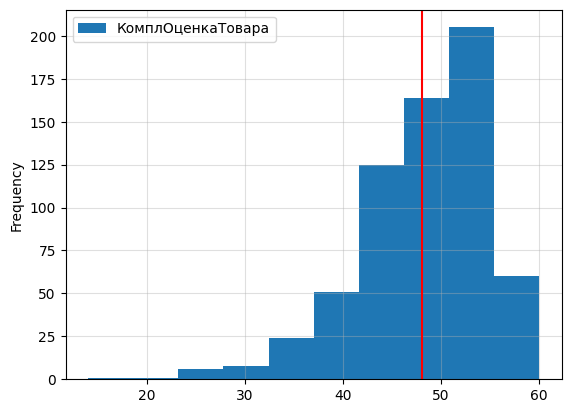

In [8]:
ax = df.plot.hist()
ax.grid(True, alpha=0.4)
ax.axvline(s.mean(), color='r')

In [9]:
x = s.dropna().to_numpy()

mu = 0.0      # ЗАДАНО заранее
sigma = 1.0   # ЗАДАНО заранее

# KS тест против N(mu, sigma)
D, p = stats.kstest(x, 'norm', args=(mu, sigma))
print(D, p)

# D’Agostino–Pearson (скошенность+эксцесс)
print(stats.normaltest(x))

# Shapiro–Wilk (хорош на малых/средних n, но на больших станет “слишком” чувствительным)
print(stats.shapiro(x))

# Anderson–Darling (часто сильнее KS именно для нормальности)
print(stats.anderson(x, dist='norm'))

1.0 0.0
NormaltestResult(statistic=np.float64(120.78774690312635), pvalue=np.float64(5.905735865692873e-27))
ShapiroResult(statistic=np.float64(0.9391247922802091), pvalue=np.float64(1.3992492658619792e-15))
AndersonResult(statistic=np.float64(8.860639075442577), critical_values=array([0.572, 0.652, 0.782, 0.912, 1.085]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(48.035658914728685), scale=np.float64(6.602062994557179))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


## 8.11 Практика сравнения групп

In [10]:
path = "./data/task_aggressor.sav"
# df = read_pspp(path)

In [11]:
df

,КомплОценкаТовара
0,47.0
1,54.0
2,37.0
3,39.0
4,56.0
...,...
640,51.0
641,42.0
642,42.0
643,60.0


## 9.4 Корреляция переменных

In [12]:
df = pd.read_spss('./data/Correlate.sav')

In [13]:
pd.set_option('future.no_silent_downcasting', True)

In [14]:
df = \
(df
 .replace({'Очень доволен':9, 'очень доволен':9, 'крайне доволен':7, 'крайне недоволен':3})
 .astype({'РаботаМаг':int, 'КачОбсл':int, 'Ассортимент':int})
 .assign(КачОбсл = lambda df: df['КачОбсл'].abs())
)

C:\Users\ilyao\AppData\Local\Temp\ipykernel_22724\1450062438.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  .replace({'Очень доволен':9, 'очень доволен':9, 'крайне доволен':7, 'крайне недоволен':3})


In [15]:
df.dtypes

№анк           object
РаботаМаг       int64
КачОбсл         int64
Ассортимент     int64
dtype: object

In [16]:
df[['РаботаМаг', 'КачОбсл']].corr(method='pearson')

,РаботаМаг,КачОбсл
РаботаМаг,1.000000,0.779913
КачОбсл,0.779913,1.000000


In [17]:
rho, p = stats.spearmanr(df['РаботаМаг'], df['КачОбсл'], nan_policy='omit')
print(f"{rho=:g}, {p=:g}")

df[['РаботаМаг', 'КачОбсл']].corr(method='spearman')

rho=0.784205, p=7.90545e-07


,РаботаМаг,КачОбсл
РаботаМаг,1.000000,0.784205
КачОбсл,0.784205,1.000000


In [18]:
df[['РаботаМаг', 'КачОбсл']].corr(method='kendall')

,РаботаМаг,КачОбсл
РаботаМаг,1.000000,0.673665
КачОбсл,0.673665,1.000000


<Axes: xlabel='РаботаМаг', ylabel='КачОбсл'>

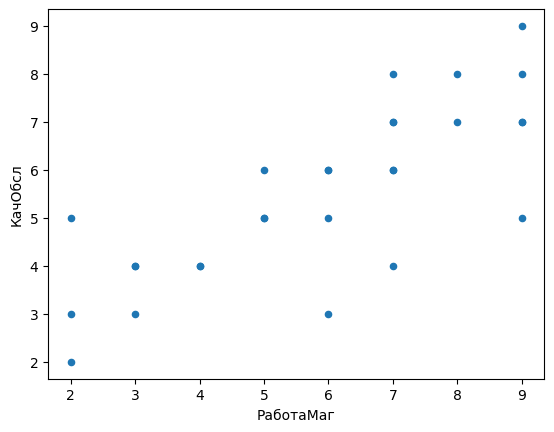

In [19]:
df.plot.scatter('РаботаМаг', 'КачОбсл')

In [20]:
x = df['РаботаМаг'].dropna().to_numpy()

z = (x - x.mean()) / x.std(ddof=1)
D, p = stats.kstest(z, 'norm')
print(f"D={D:.4f}, p={p:.4g}")

x = df['РаботаМаг'].dropna().to_numpy()
D, p = lilliefors(x, dist='norm')
print(f"lilliefors: D={D:.4f}, p={p:.4g}")

D=0.1481, p=0.5234
lilliefors: D=0.1481, p=0.122


In [21]:
x = df['КачОбсл'].dropna().to_numpy()

z = (x - x.mean()) / x.std(ddof=1)
D, p = stats.kstest(z, 'norm')
print(f"D={D:.4f}, p={p:.4g}")

x = df['РаботаМаг'].dropna().to_numpy()
D, p = lilliefors(x, dist='norm')
print(f"lilliefors: D={D:.4f}, p={p:.4g}")

D=0.1197, p=0.7733
lilliefors: D=0.1481, p=0.122


## 9.5 Регрессия

In [25]:
path = './data/Regression.sav'

df = read_pspp(path)

In [27]:
df.head()

,НомерАнкеты,Лояльность,Цена,Сервис,Ассортимент,Допуслуги
0,3456,93.0,8.0,7.0,7.0,9.0
1,3457,51.0,5.0,6.0,4.0,7.0
2,3458,63.0,6.0,6.0,5.0,7.0
3,3459,72.0,7.0,5.0,6.0,10.0
4,3460,58.0,6.0,6.0,5.0,9.0


In [31]:
# 3) Подставьте сюда ТОЧНЫЕ названия столбцов из df.columns:
y_col = "Лояльность"
x_cols = ["Сервис", "Ассортимент", "Цена", "Допуслуги"]

# 4) Данные для модели
X = df[x_cols]
y = df[y_col]

# 5) Добавляем константу (свободный член), как в стандартной регрессии
X = sm.add_constant(X)

# 6) OLS-регрессия
model = sm.OLS(y, X, missing="drop").fit()

# 7) Полный отчет как в PSPP/SPSS
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Лояльность   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     47.02
Date:                 Сб, 27 дек 2025   Prob (F-statistic):           3.24e-14
Time:                        11:36:04   Log-Likelihood:                -154.04
No. Observations:                  43   AIC:                             318.1
Df Residuals:                      38   BIC:                             326.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -11.9660      5.786     -2.068      

In [32]:
print("R²:", model.rsquared)
print("Adj. R²:", model.rsquared_adj)
print("F:", model.fvalue)
print("p(F):", model.f_pvalue)

R²: 0.8319061849693086
Adj. R²: 0.8142120991766042
F: 47.01605919150232
p(F): 3.2430446323297516e-14


## 9.6 Факторный анализ

In [74]:
df, meta = pyreadstat.read_sav('./data/Factor.sav', apply_value_formats=False)
df

,p1,p5,p6,p7,p8,p9,p10,p11,p12,p13,...,p75,p77,p78,p79,p80,p81,p87,p88,p112,p117
0,53.0,5.0,5.0,5.0,5.0,2.0,5.0,5.0,5.0,3.0,...,4.0,4.0,4.0,5.0,2.0,5.0,5.0,5.0,2.0,4.0
1,54.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,...,5.0,2.0,4.0,2.0,4.0,5.0,4.0,5.0,1.0,5.0
2,55.0,4.0,5.0,5.0,5.0,4.0,5.0,4.0,4.0,4.0,...,3.0,4.0,5.0,3.0,3.0,4.0,4.0,3.0,3.0,3.0
3,56.0,5.0,2.0,4.0,5.0,5.0,5.0,4.0,5.0,4.0,...,5.0,1.0,2.0,5.0,2.0,4.0,3.0,3.0,2.0,4.0
4,57.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,...,5.0,2.0,4.0,2.0,4.0,5.0,4.0,5.0,1.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505,494.0,5.0,5.0,5.0,4.0,4.0,5.0,5.0,4.0,4.0,...,4.0,1.0,2.0,5.0,4.0,4.0,5.0,5.0,5.0,4.0
506,495.0,5.0,5.0,4.0,4.0,4.0,5.0,5.0,5.0,4.0,...,4.0,2.0,2.0,5.0,4.0,4.0,5.0,5.0,4.0,4.0
507,496.0,5.0,4.0,4.0,5.0,4.0,4.0,5.0,5.0,4.0,...,4.0,1.0,2.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
508,497.0,5.0,NaN,4.0,4.0,4.0,5.0,4.0,3.0,4.0,...,5.0,1.0,2.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0


In [77]:
rep = factor_analysis_spss_like(
    df,
    exclude=["p1"],          # номер анкеты (или как он у вас называется)
    dropna="listwise",
    eigen_threshold=1.0,
    rotation="varimax",
    loading_cutoff=0.50,
    suppress_below=0.30      # опционально: как в SPSS “Suppress small coefficients”
)

Как по выводу отвечать на ваши вопросы

1. Сколько факторов получилось?
Берёте:

rep["summary"]["n_factors_kaiser"]
или просто число строк в rep["total_variance_explained"] с Eigenvalue > 1.

2. Какой % дисперсии они объясняют?
Берёте:

rep["summary"]["total_variance_explained_extracted_cum_%"]
или сумму % of Variance первых k компонент в total_variance_explained.

3. Как назвать первый фактор?
Смотрите:

rep["factor_groups_|loading|>=cutoff"]["Component 1"]
Это список переменных с |нагрузкой| ≥ 0.5, отсортированных по величине. По их смыслу и называете фактор.

4. Разные шкалы (1–10, 1–7, 1–100, …)
В факторном анализе, чтобы не “перетягивали” признаки с большой дисперсией:

используют матрицу корреляций (как в вашем задании) — это уже по сути приводит шкалы к сопоставимому виду;

или перед анализом делают стандартизацию (z-score).

In [83]:
rep.keys()

dict_keys(['summary', 'correlation_matrix', 'total_variance_explained', 'unrotated_component_matrix', 'rotated_component_matrix', 'rotated_component_matrix_display', 'communalities', 'factor_groups_|loading|>=cutoff'])

In [78]:
rep["summary"]

{'n_rows_used': 296,
 'n_variables': 33,
 'n_factors_kaiser': 8,
 'eigen_threshold': 1.0,
 'rotation': 'varimax',
 'dropna': 'listwise',
 'total_variance_explained_extracted_%': 66.06920014341108,
 'total_variance_explained_extracted_cum_%': 66.0692001434111}

In [79]:
rep["total_variance_explained"].head(20)

,Component,Eigenvalue,% of Variance,Cumulative %
0,1,11.394144,34.527710,34.527710
1,2,2.334318,7.073692,41.601402
2,3,1.807241,5.476487,47.077890
3,4,1.546217,4.685505,51.763395
4,5,1.455013,4.409129,56.172524
5,6,1.216235,3.685560,59.858084
6,7,1.045032,3.166763,63.024847
7,8,1.004636,3.044353,66.069200
8,9,0.874275,2.649317,68.718518
9,10,0.854070,2.588092,71.306610


In [80]:
rep["rotated_component_matrix_display"]

,Component 1,Component 6,Component 4,Component 3,Component 2,Component 5,Component 8,Component 7
p5,,,,,-0.703932,,,
p6,,,-0.370982,,-0.453854,-0.439792,,
p7,,,,0.41189,-0.440653,-0.408218,,
p8,0.592156,,,,-0.621029,,,
p9,0.490147,,,,-0.630979,,,
p10,,,-0.436214,,-0.526422,,,
p11,0.325796,,,,-0.492044,,,
p12,,,,,,-0.814315,,
p13,0.692317,,,,,,,
p15,0.828824,,,,,,,


In [81]:
rep["factor_groups_|loading|>=cutoff"]["Component 1"]   # переменные для названия 1-го фактора

p15    0.828824
p17    0.799455
p23    0.714458
p13    0.692317
p8     0.592156
Name: Component 1, dtype: float64

## 9.7 Анализ надежности-согласованности

In [85]:
# df = pd.read_spss('./data/CallCenterVC.sav')
# df = read_pspp('./data/CallCenterVC.sav')
df, meta = pyreadstat.read_sav('./data/CallCenterVC.sav', apply_value_formats=False)
df

,p17,p18,p19,p23,p25,p26,p30,p41,p65
0,3.0,4.0,3.0,5.0,3.0,4.0,4.0,4.0,4.0
1,2.0,3.0,2.0,2.0,5.0,2.0,4.0,5.0,4.0
2,2.0,4.0,3.0,4.0,3.0,4.0,3.0,NaN,4.0
3,3.0,4.0,3.0,5.0,5.0,4.0,4.0,5.0,4.0
4,3.0,3.0,1.0,4.0,NaN,NaN,4.0,NaN,4.0
...,...,...,...,...,...,...,...,...,...
734,4.0,5.0,4.0,4.0,4.0,3.0,4.0,4.0,4.0
735,4.0,5.0,4.0,4.0,5.0,4.0,4.0,5.0,4.0
736,3.0,4.0,2.0,5.0,4.0,5.0,4.0,4.0,4.0
737,3.0,4.0,3.0,4.0,4.0,4.0,3.0,5.0,4.0


In [86]:
report = cronbach_alpha_report(df, dropna="listwise")  # SPSS-подобно

In [87]:
report.keys()

dict_keys(['summary', 'item_table'])

In [88]:
report["summary"]          # общая альфа, стандартизированная альфа, что удалили

{'n_items': 9,
 'n_rows_used': 642,
 'alpha': 0.7748129891500275,
 'alpha_standardized': 0.7659900987921965,
 'kept_items_after_pruning': ['p17', 'p18', 'p19', 'p23', 'p30', 'p65'],
 'removed_steps': [{'remove': 'p25',
   'alpha_new': np.float64(0.8018256959779217),
   'gain': np.float64(0.02701270682789425)},
  {'remove': 'p26',
   'alpha_new': np.float64(0.8104905466525774),
   'gain': np.float64(0.008664850674655611)},
  {'remove': 'p41',
   'alpha_new': np.float64(0.8153206494297661),
   'gain': np.float64(0.004830102777188761)}],
 'alpha_after_pruning': 0.8153206494297661}

In [89]:
report["item_table"]       # аналог "alpha if item deleted" + item-total corr

,item,item_total_corr,alpha_if_deleted,alpha_std_if_deleted
4,p25,0.024166,0.801826,0.803679
5,p26,0.332747,0.772679,0.759821
7,p41,0.379140,0.765351,0.754092
6,p30,0.473154,0.751842,0.740228
3,p23,0.525633,0.743058,0.732048
1,p18,0.537594,0.741321,0.731622
2,p19,0.575946,0.734044,0.724914
8,p65,0.619751,0.731570,0.718878
0,p17,0.633357,0.724757,0.716386


## 10.2 Логистическая регрессия

In [96]:
path = './data/LogRegrAssignm.sav'

# df, meta = pyreadstat.read_sav(path, apply_value_formats=False)
df = read_pspp(path)
df.head(10)

,Группа,ДоходМес,ОценкаИнтернет,ВремяПрилож
0,0.0,48.5,5.0,4.0
1,0.0,55.5,4.0,5.0
2,0.0,50.0,6.0,3.0
3,0.0,58.5,5.0,7.0
4,0.0,61.0,3.0,6.0
5,0.0,61.5,5.0,5.0
6,0.0,61.5,5.0,7.0
7,0.0,62.0,4.0,3.0
8,0.0,62.0,8.0,7.0
9,0.0,62.0,5.0,5.0


In [106]:
rep = logit_spss_like(df, y_col="Группа", x_cols=["ДоходМес", "ОценкаИнтернет", "ВремяПрилож"])

In [105]:
rep.keys()

dict_keys(['data_used', 'coef_table', 'pred_prob', 'pred_class', 'accuracy', 'classification_table'])

In [108]:
rep["coef_table"]

,B,S.E.,Wald,Sig.,Exp(B)
const,-26.564272,10.715175,6.146067,0.013170,2.905919e-12
ДоходМес,0.163729,0.078594,4.339846,0.037230,1.177896e+00
ОценкаИнтернет,1.867219,0.848690,4.840525,0.027798,6.470278e+00
ВремяПрилож,0.346981,0.168421,4.244447,0.039379,1.414790e+00


In [109]:
rep["classification_table"]

Predicted,0,1,% correct
Observed,,,
0.0,29.0,2.0,93.548387
1.0,1.0,27.0,96.428571
Overall,NaN,NaN,94.915254


In [102]:
p9, cls9 = prob_for_row(rep, 9)
print(p9, cls9)

0.7218333789728298 1


## 10.4 Кластерный анализ

In [112]:
path = './data/Klaster_assignment.sav'

df, meta = pyreadstat.read_sav(path, apply_value_formats=False)
# df = read_pspp(path)
df.head(10)

,p8,p9,p13,p73,p81,p112,p117
0,5.0,2.0,3.0,4.0,5.0,2.0,4.0
1,5.0,5.0,4.0,3.0,5.0,1.0,5.0
2,5.0,4.0,4.0,4.0,4.0,3.0,3.0
3,5.0,5.0,4.0,5.0,4.0,2.0,4.0
4,5.0,5.0,4.0,3.0,5.0,1.0,5.0
5,3.0,3.0,3.0,5.0,4.0,3.0,4.0
6,5.0,3.0,5.0,5.0,5.0,5.0,5.0
7,2.0,1.0,3.0,4.0,5.0,1.0,4.0
8,3.0,3.0,3.0,5.0,3.0,1.0,2.0
9,5.0,5.0,5.0,3.0,4.0,5.0,4.0


In [113]:
rep = kmeans_3_spss_like(df, k=3, n_init=50, order_by="p8")

In [114]:
print("Размеры кластеров:\n", rep["sizes"])
print("\nЦентры/средние:\n", rep["means"].round(3))

Размеры кластеров:
 1     85
2    184
3    241
Name: count, dtype: int64

Центры/средние:
             p8     p9    p13    p73    p81   p112   p117
Cluster                                                 
1        2.400  2.118  2.353  2.776  2.471  1.576  2.106
2        3.413  2.533  3.620  4.109  3.864  3.022  3.478
3        4.581  4.253  4.373  4.436  4.315  3.855  4.041


In [115]:
diff_23 = (rep["means"].loc[3] - rep["means"].loc[2]).sort_values(key=lambda s: s.abs(), ascending=False)
print("\nКлючевые отличия (Cluster3 - Cluster2):\n", diff_23.round(3))


Ключевые отличия (Cluster3 - Cluster2):
 p9      1.721
p8      1.168
p112    0.833
p13     0.754
p117    0.563
p81     0.451
p73     0.327
dtype: float64
